# 🎧 Spotify Seasonality Analysis — Christmas Peak vs Summer Hits
---

#### This notebook analyzes seasonality and audio features (danceability, valence, tempo, energy) across the European Spotify charts.

In [ ]:
# --- Imports and setup ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

In [109]:
# --- Load dataset ---
df = pd.read_csv('../data/eu_top200_with_custom_popularity.csv')
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4520058 entries, 0 to 4520057
Data columns (total 28 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   title                  str    
 2   rank                   int64  
 3   date                   str    
 4   country                str    
 5   chart                  str    
 6   streams                float64
 7   track_id               str    
 8   popularity             int64  
 9   duration_ms            int64  
 10  explicit               int64  
 11  artists                str    
 12  id_artists             str    
 13  danceability           float64
 14  energy                 float64
 15  key                    int64  
 16  loudness               float64
 17  mode                   int64  
 18  speechiness            float64
 19  acousticness           float64
 20  instrumentalness       float64
 21  liveness               float64
 22  valence                float6

,Unnamed: 0,title,rank,date,country,chart,streams,track_id,popularity,duration_ms,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,main_artist,id_main_artist,normalized_popularity
0,0,Alone,1,2017-01-01,Austria,top200,12990.0,0JiVRyTJcJnmlwCZ854K4p,66,161200,...,0.0458,0.1860,0.000405,0.1210,0.157,97.019,4,Alan Walker,7vk5e3vY1uw9plTHJAMwjN,8.164351
1,1,Rockabye (feat. Sean Paul & Anne-Marie),2,2017-01-01,Austria,top200,12897.0,5knuzwU65gJK7IF5yJsuaW,78,251088,...,0.0523,0.4060,0.000000,0.1800,0.742,101.965,4,Clean Bandit,6MDME20pz9RveH9rEXvrOM,23.522081
2,2,Bad Ideas,4,2017-01-01,Austria,top200,10837.0,76gwG061wqdatYhicO2hG4,57,166213,...,0.0331,0.0163,0.023700,0.0892,0.678,120.005,4,Alle Farben,61ipISvUVa5LkJlKZnm3Oo,2.431793
3,3,Closer,5,2017-01-01,Austria,top200,10317.0,7BKLCZ1jbUBVqRi2FVlTVw,86,244960,...,0.0338,0.4140,0.000000,0.1110,0.661,95.010,4,The Chainsmokers,69GGBxA162lTqCwzJG5jLp,11.683320
4,4,Call On Me - Ryan Riback Extended Remix,8,2017-01-01,Austria,top200,9146.0,78rIJddV4X0HkNAInEcYde,50,222041,...,0.0362,0.0604,0.000611,0.1590,0.717,104.998,4,Starley,02A3cEvlLLCbIMVDrK2GHV,18.511417


In [110]:
# Convert and extract date components
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [111]:
# --- Define temporal windows ---
df['is_christmas_period'] = ((df['date'].dt.month == 12) & (df['date'].dt.day >= 10)) | \
                            ((df['date'].dt.month == 1) & (df['date'].dt.day <= 7))
df['is_summer_period'] = df['date'].dt.month.isin([6,7,8])

# Subsets
christmas_df = df[df['is_christmas_period']]
summer_df = df[df['is_summer_period']]

#### 💭 **Hypothesis:** The most popular Christmas songs are the ones generating the highest total streams during the Christmas window; also in summer we expect a similar trend for "Summer Hits"

In [115]:
# Aggregate by Country and Track_id using streams, let's see if we spot any interesting patterns in the top Christmas hits across different European countries.
top_christmas_by_country = (
    christmas_df
    .groupby(["country", "track_id"], as_index=False)
    .agg(
        artist_name=("main_artist", "first"), # all rows in the group refer to the same track, 'first' is just a convenient way to get the artist name without needing to reset the index or do additional merges
        track_name=("title", "first"),
        total_streams=("streams", "sum")
    )
    .sort_values(["country", "total_streams"], ascending=[True, False])
)

for country, group in top_christmas_by_country.groupby("country"):
    
    print(f"\n🎄 {country}")
    
    display(
        group.sort_values("total_streams", ascending=False)
             .head(10)[["artist_name", "track_name", "total_streams"]]
    )


🎄 Austria


,artist_name,track_name,total_streams
97,Mariah Carey,All I Want for Christmas Is You,3795091.0
313,Wham!,Last Christmas,3705502.0
116,Ariana Grande,Santa Tell Me,2190975.0
297,Chris Rea,Driving Home for Christmas - 2019 Remaster,2056366.0
530,Kelly Clarkson,Underneath the Tree,1902923.0
72,Melanie Thornton,Wonderful Dream (Holidays Are Coming) - Radio ...,1894323.0
687,Pentatonix,Hallelujah,1666031.0
1021,Justin Bieber,Mistletoe,1572120.0
352,"""Shakin Stevens""",Merry Christmas Everyone,1474949.0
3,Band Aid,Do They Know It's Christmas? - 1984 Version,1446013.0



🎄 Belgium


,artist_name,track_name,total_streams
1110,Mariah Carey,All I Want for Christmas Is You,4016999.0
1313,Wham!,Last Christmas,2987328.0
1262,Tones And I,Dance Monkey,2698710.0
1123,Ariana Grande,Santa Tell Me,1931422.0
1312,Brenda Lee,Rockin' Around The Christmas Tree,1717883.0
1799,Arizona Zervas,ROXANNE,1404075.0
1987,Lewis Capaldi,Someone You Loved,1399264.0
1401,Regard,Ride It,1398910.0
2004,Bobby Helms,Jingle Bell Rock,1374563.0
1354,Lady Gaga,Shallow,1346619.0



🎄 Bulgaria


...

,artist_name,track_name,total_streams
16478,Wham!,Last Christmas,671712.0
16329,Mariah Carey,All I Want for Christmas Is You,613113.0
16477,Brenda Lee,Rockin' Around The Christmas Tree,457836.0
16429,Tones And I,Dance Monkey,345431.0
16339,Ariana Grande,Santa Tell Me,319823.0
17024,Bobby Helms,Jingle Bell Rock,308993.0
16551,Dean Martin,Let It Snow! Let It Snow! Let It Snow!,301866.0
16381,Andy Williams,It's the Most Wonderful Time of the Year,266332.0
16644,Kelly Clarkson,Underneath the Tree,246614.0
16273,Band Aid,Do They Know It's Christmas? - 1984 Version,245225.0



🎄 Spain


,artist_name,track_name,total_streams
17910,KAROL G,Tusa,15980554.0
17534,Bad Bunny,DÁKITI,15419342.0
17097,C. Tangana,Tú Me Dejaste De Querer,12304421.0
17323,Bad Bunny,LA NOCHE DE ANOCHE,11999994.0
17745,Paulo Londra,Adan y Eva,11179872.0
17765,Omar Montes,Alocao (With Bad Gyal),10899158.0
17938,KAROL G,BICHOTA,10080818.0
17239,Tones And I,Dance Monkey,9695012.0
17444,Boza,Hecha Pa' Mi,9335033.0
17105,Mariah Carey,All I Want for Christmas Is You,9264151.0



🎄 Sweden


,artist_name,track_name,total_streams
18260,Wham!,Last Christmas,14022956.0
18034,Mariah Carey,All I Want for Christmas Is You,13969092.0
18020,Triad,Tänd ett ljus,10427013.0
18041,Freddy Kalas,Hey Ho,9307625.0
18767,Adolphson & Falk,Mer jul,9029820.0
18552,Tommy Körberg,Julen är här,8408328.0
18425,The Pogues,Fairytale of New York (feat. Kirsty MacColl),7881105.0
18594,Bing Crosby,White Christmas,7564250.0
18132,Just D,Juligen,6548810.0
18052,Ariana Grande,Santa Tell Me,6543309.0


##### 👉 We can see that in many countries the Top 10 is dominated by recurring Christmas classics, while in a few (e.g., France/Spain/Italy/Greece) there are more “regular” hits mixing in.

#### Let's see a Pan-European analysis for Christmas:

In [89]:
# Aggregate Total Christmas Streams (Pan-European)
top_christmas_tracks = (
    christmas_df
    .groupby("track_id", as_index=False)
    .agg(
        artist_name=("main_artist", "first"), # all rows in the group refer to the same track, 
        track_name=("title", "first"),        #"first" value is perfectly safe for our purposes 
        total_streams=("streams", "sum")
    )
    .sort_values("total_streams", ascending=False)
)

top_christmas_tracks.head(30)

,track_id,artist_name,track_name,total_streams
553,0bYg9bo50gSsH3LtXe2SQn,Mariah Carey,All I Want for Christmas Is You,132159697.0
2045,2FRnf9qhLbvw8fu4IBXx78,Wham!,Last Christmas,115265905.0
1708,1rgnBhdG2JDFTbYkYRZAku,Tones And I,Dance Monkey,76304217.0
697,0lizgQ7Qw35od7CYaoMBZb,Ariana Grande,Santa Tell Me,64001779.0
2039,2EjXfH91m7f8HiJN1yQg97,Brenda Lee,Rockin' Around The Christmas Tree,42664169.0
3438,3nAp4IvdMPPWEH9uuXFFV5,Kelly Clarkson,Underneath the Tree,42362599.0
6958,7xapw9Oy21WpfEcib2ErSA,Justin Bieber,Mistletoe,40630126.0
28,0247StOpd3AkeBQzANX4Zf,Band Aid,Do They Know It's Christmas? - 1984 Version,39807975.0
1954,27qAMKrDdKEs8HDXcvR24R,Chris Rea,Driving Home for Christmas - 2019 Remaster,36793527.0
6922,7vQbuQcyTflfCIOu3Uzzya,Bobby Helms,Jingle Bell Rock,35535786.0


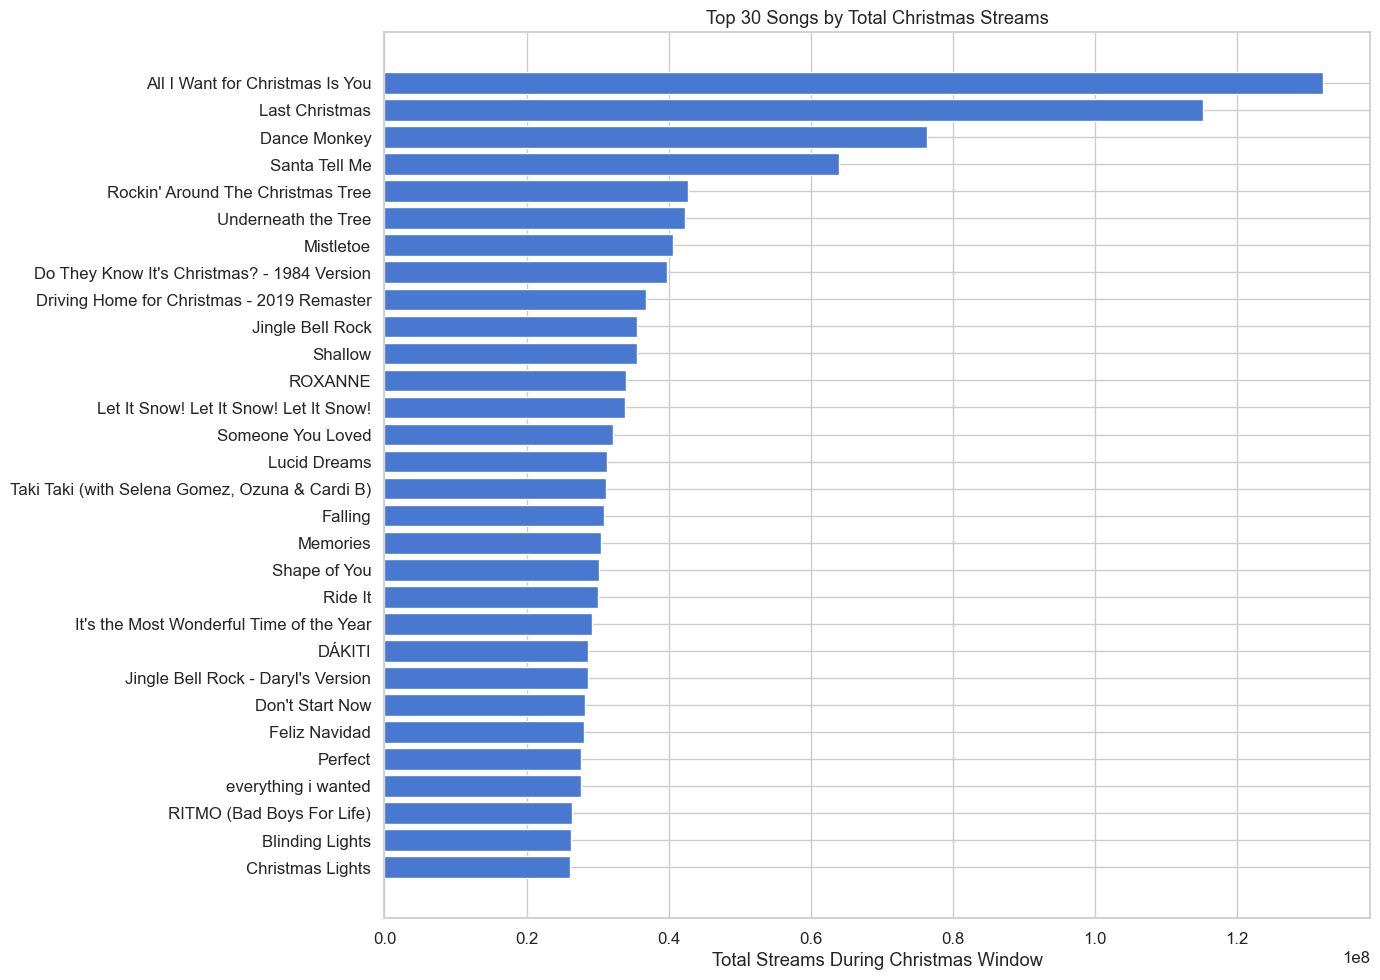

In [87]:
top30 = top_christmas_tracks.head(30)

plt.figure(figsize=(14,10))
plt.barh(top30["track_name"], top30["total_streams"])
plt.gca().invert_yaxis()

plt.xlabel("Total Streams During Christmas Window")
plt.title("Top 30 Songs by Total Christmas Streams")
plt.tight_layout()
plt.show()

##### 👉 We can see that in Europe the Top 30 is dominated by recurring Christmas classics, whith the exception of 'Dance Monkey'

#### Pan-European analysis for Summer:

In [90]:
# Aggregate Total Summer Streams (Pan-European)
top_summer_tracks = (
    summer_df
    .groupby("track_id", as_index=False)
    .agg(
        artist_name=("main_artist", "first"), # all rows in the group refer to the same track, 
        track_name=("title", "first"),        #"first" value is perfectly safe for our purposes 
        total_streams=("streams", "sum")
    )
    .sort_values("total_streams", ascending=False)
)

top_summer_tracks.head(30)

,track_id,artist_name,track_name,total_streams
593,0VjIjW4GlUZAMYd2vXMi3b,The Weeknd,Blinding Lights,173380824.0
8948,7ytR5pFWmSjzHJIeQkgog4,DaBaby,ROCKSTAR (feat. Roddy Ricch),168117372.0
4041,3Wrjm47oTz2sjIgck11l5e,Måneskin,Beggin',166988673.0
5524,4pt5fDVTg5GhEvEtlz9dKk,Måneskin,I WANNA BE YOUR SLAVE,145147553.0
2265,1xQ6trAsedVPCdbtDAmk0c,Jawsh 685,Savage Love (Laxed - Siren Beat),145075603.0
2588,2Fxmhks0bxGSBdJ92vM42m,Billie Eilish,bad guy,138943648.0
8778,7qiZfU4dY1lWllzX7mPBI3,Ed Sheeran,Shape of You,135286156.0
8771,7qEHsqek33rTcFNT9PFqLf,Lewis Capaldi,Someone You Loved,133290216.0
7408,6UelLqGlWMcVH1E5c4H7lY,Harry Styles,Watermelon Sugar,128201188.0
3779,3H7ihDc1dqLriiWXwsc2po,Topic,Breaking Me,128039509.0


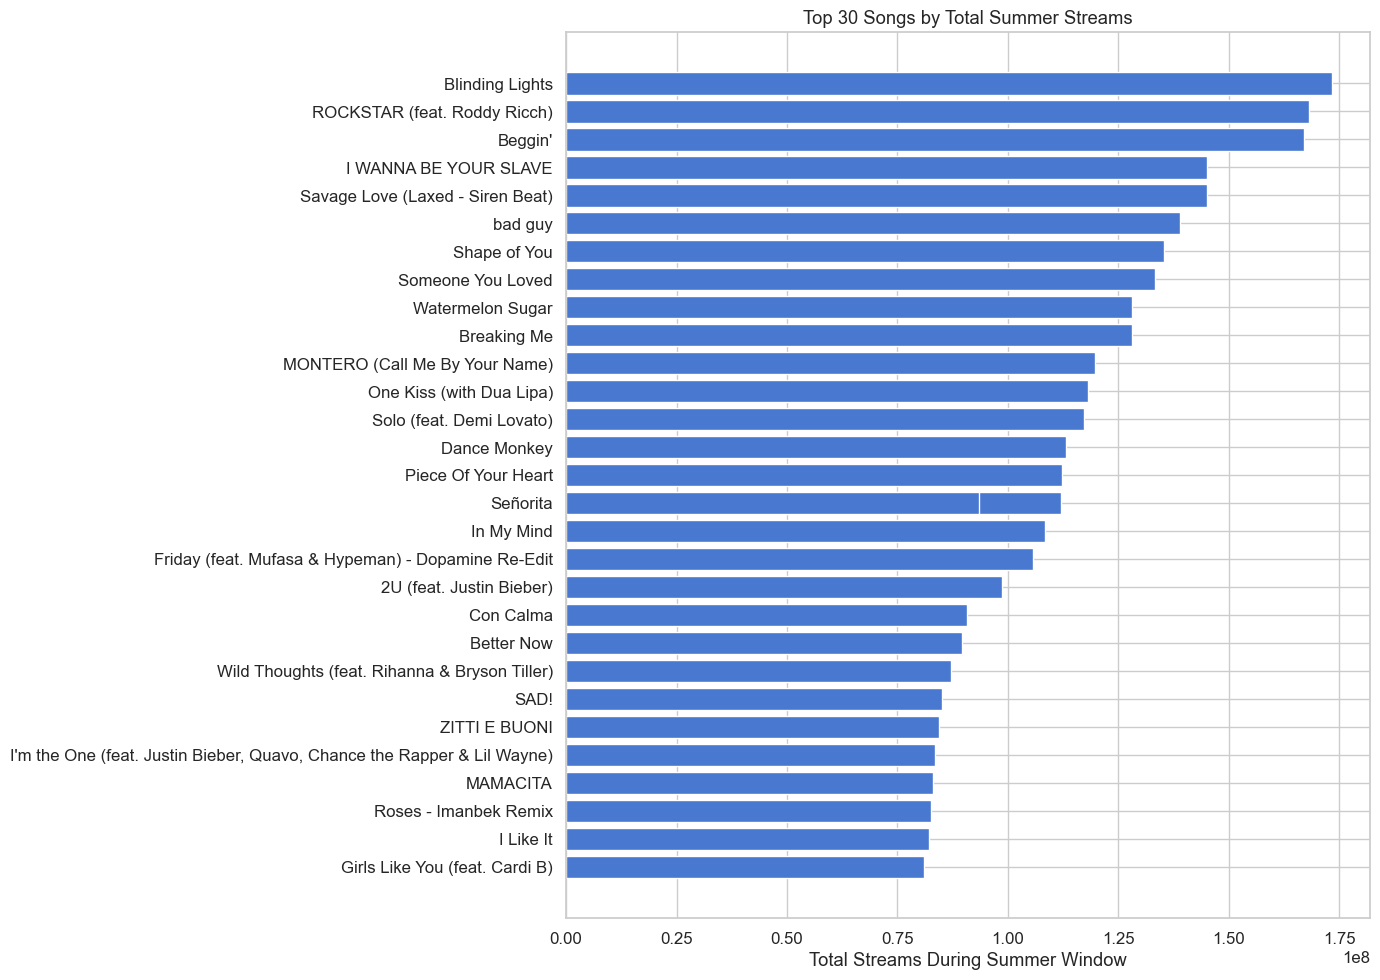

In [91]:
top30 = top_summer_tracks.head(30)

plt.figure(figsize=(14,10))
plt.barh(top30["track_name"], top30["total_streams"])
plt.gca().invert_yaxis()

plt.xlabel("Total Streams During Summer Window")
plt.title("Top 30 Songs by Total Summer Streams")
plt.tight_layout()
plt.show()

##### 👉 We can see that in Europe the Top 30 Summer hits have no a clear dominance by any recurring hits. 

##### 👉 This reinforces the idea that Christmas hits have a seasonality, while summer hits renew roughly every summer.

##### 🔎 Let's verify seasonality for a well-known set of Christmas and Summer songs 

🎄 Christmas tracks found: 20/20
☀️  Summer tracks found:   20/20


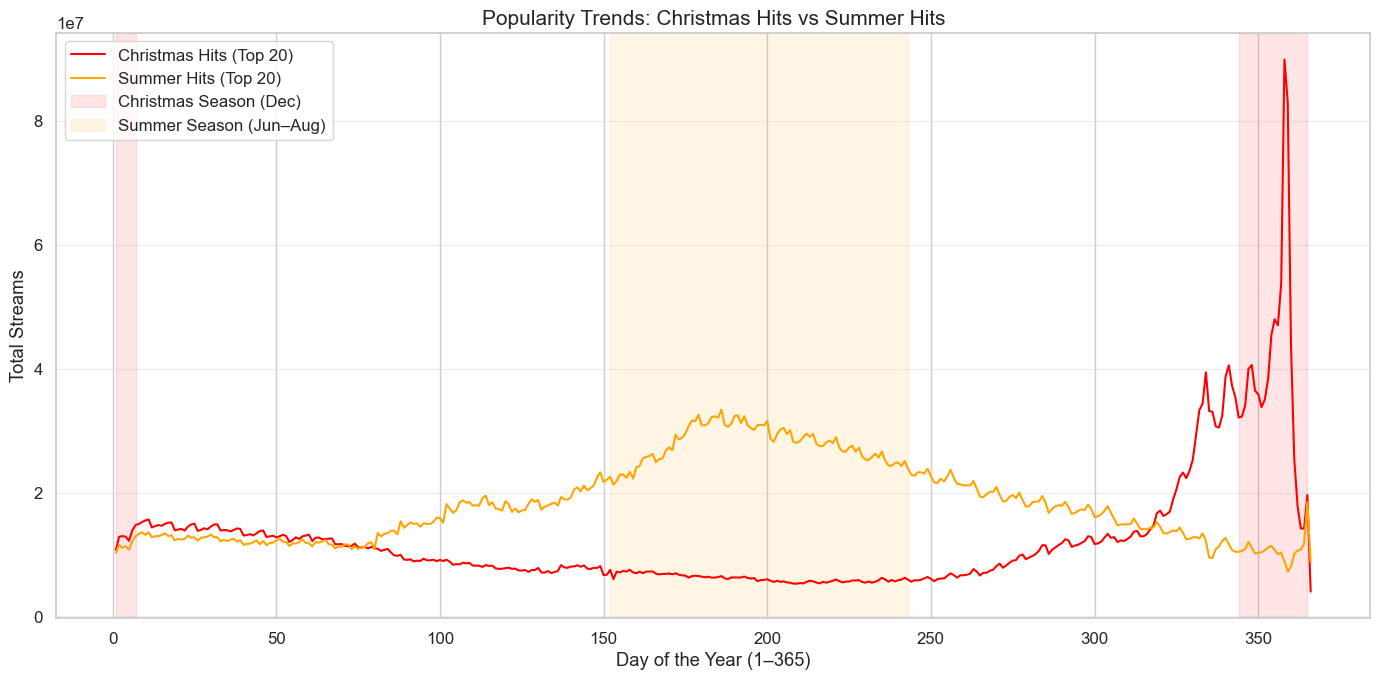

In [101]:

# =============================================================
# MASKS
# =============================================================
# Use sets for O(1) lookup — much faster than lists with .isin()
christmas_tracks_ids = set(top_christmas_tracks.head(20)['track_id'].tolist())
summer_tracks_ids    = set(top_summer_tracks.head(20)['track_id'].tolist())

# =============================================================
# 1. Filter by Track ID
# =============================================================
df_christmas_tracks = df[df['track_id'].isin(christmas_tracks_ids)].copy()
df_summer_tracks    = df[df['track_id'].isin(summer_tracks_ids)].copy()

# ✅ Found tracks (count by track_id to avoid NaN/duplicate title issues)
print(f"🎄 Christmas tracks found: {df_christmas_tracks['track_id'].nunique()}/20")
print(f"☀️  Summer tracks found:   {df_summer_tracks['track_id'].nunique()}/20")

# =============================================================
# 2. "Day of year" column to align years
# =============================================================
df['day_of_year'] = df['date'].dt.dayofyear
df_christmas_tracks['day_of_year'] = df_christmas_tracks['date'].dt.dayofyear
df_summer_tracks['day_of_year']    = df_summer_tracks['date'].dt.dayofyear

# =============================================================
# 3. AGGREGATION: daily total streams per group
# =============================================================
sum_christmas = (
    df_christmas_tracks
    .groupby('day_of_year')['streams']
    .sum()
    .reset_index()
)

sum_summer = (
    df_summer_tracks
    .groupby('day_of_year')['streams']
    .sum()
    .reset_index()
)

# =============================================================
# 4. PLOT
# =============================================================
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=sum_christmas, x='day_of_year', y='streams',
    label=f'Christmas Hits (Top {df_christmas_tracks["track_id"].nunique()})',
    color='red'
)
sns.lineplot(
    data=sum_summer, x='day_of_year', y='streams',
    label=f'Summer Hits (Top {df_summer_tracks["track_id"].nunique()})',
    color='orange'
)

# Seasonal color bands
plt.axvspan(344, 365, color='red',    alpha=0.1, label='Christmas Season (Dec)')
plt.axvspan(1,   7,   color='red',    alpha=0.1)  # first week of January
plt.axvspan(152, 243, color='orange', alpha=0.1, label='Summer Season (Jun–Aug)')

plt.title('Popularity Trends: Christmas Hits vs Summer Hits', fontsize=15)
plt.xlabel("Day of the Year (1–365)")
plt.ylabel('Total Streams')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 📊 Popularity Seasonality: Summer Hits vs Christmas Hits

### Key Observations

**🎄 Christmas Songs (Red Line)**
The seasonality pattern of Christmas tracks is the most striking finding of this analysis.
These songs are essentially **"invisible" for ~10 months of the year**, hovering near **0 streams** 
from January through October. Starting around **day 310 (early November)**, streams begin rising 
sharply, culminating in a dramatic **peak around day 355 (late December)** — reaching over 
**1,200M total streams**, the highest value observed in the entire chart.
The cliff-drop immediately after Christmas (day 360+) is equally sharp, confirming that 
Christmas music consumption is almost entirely confined to a **~7 week window**.

---

**☀️ Summer Songs (Orange Line)**
Summer hits display a fundamentally different and **more stable** pattern throughout the year.
Rather than a sharp seasonal spike, they maintain a **consistent baseline of ~400–450M streams** 
even outside their peak season — suggesting these tracks have broader, year-round appeal.
As expected, streams rise during the **June–August window (days 152–243)**, peaking around 
**day 200 (~620M streams)**, before gradually declining in autumn.

---

### 💡 Analytical Takeaway

| | Christmas Hits | Summer Hits |
|---|---|---|
| **Peak streams** | ~1,200M | ~620M |
| **Peak period** | Late Dec (day ~355) | Mid July (day ~200) |
| **Off-season streams** | ~0 | ~400M |
| **Seasonality intensity** | ⭐⭐⭐⭐⭐ Extreme | ⭐⭐ Moderate |

> The data confirms a clear asymmetry: **Christmas songs are seasonal phenomena** with extreme 
> concentration of plays in a narrow window, while **summer hits are evergreen tracks** that happen 
> to peak in summer but sustain listener interest year-round. 
> This has direct implications for playlist strategy and music marketing campaigns.

#### 📈 Differential distribution of audio features between Christmas and Summer

🎄 Christmas rows after filter: 47,592
☀️  Summer rows after filter:   129,649


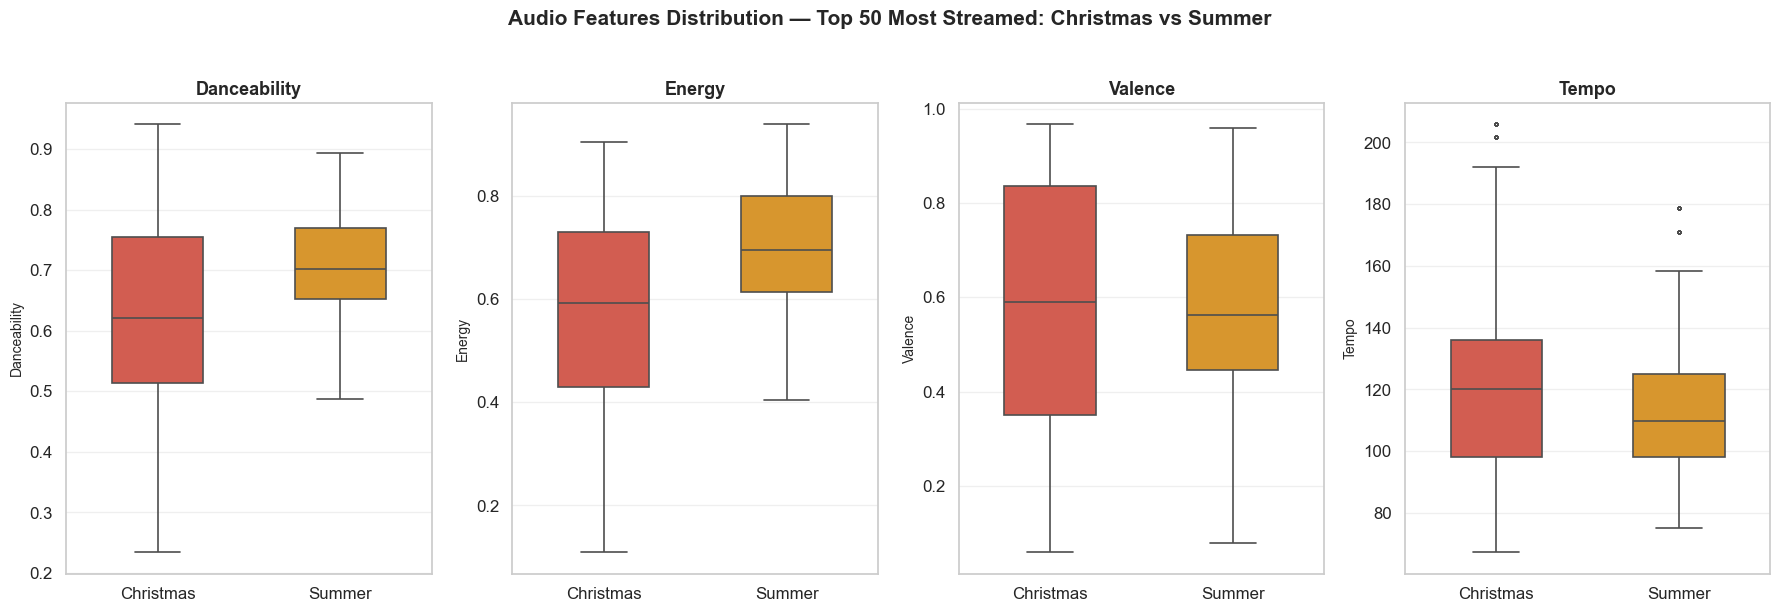

In [116]:
features = ['danceability', 'energy', 'valence', 'tempo']

# =============================================================
# 1. TOP 50 FILTER by total streams in each period
# =============================================================
top50_xmas_titles = (
    christmas_df.groupby('title')['streams']
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index                        # returns the title index directly
)

top50_summer_titles = (
    summer_df.groupby('title')['streams']
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index
)

# Apply the filter
df_xmas   = christmas_df[christmas_df['title'].isin(top50_xmas_titles)]
df_summer = summer_df[summer_df['title'].isin(top50_summer_titles)]

print(f"🎄 Christmas rows after filter: {len(df_xmas):,}")
print(f"☀️  Summer rows after filter:   {len(df_summer):,}")

# =============================================================
# 2. ADD SEASON LABEL & STACK
# =============================================================
df_xmas['season']   = 'Christmas'
df_summer['season'] = 'Summer'     

df_seasonal = pd.concat([df_xmas, df_summer], ignore_index=True)

# =============================================================
# 3. PLOT
# =============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

palette = {'Christmas': '#e74c3c', 'Summer': '#f39c12'}

for ax, feature in zip(axes, features):
    sns.boxplot(
        data      = df_seasonal,
        x         = 'season',
        y         = feature,
        hue       = 'season',    # ✅ FutureWarning fix
        palette   = palette,
        legend    = False,       # ✅ avoids duplicate legend
        width     = 0.5,
        linewidth = 1.2,
        flierprops= dict(marker='o', markersize=2, alpha=0.3),
        ax        = ax
    )
    ax.set_title(feature.capitalize(), fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(feature.capitalize(), fontsize=10)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Audio Features Distribution — Top 50 Most Streamed: Christmas vs Summer',
    fontsize=15, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()

#### 🕺 💃 Pair-wise T-test between Christmas and Summer

In [117]:
from scipy import stats

features = ['danceability', 'energy', 'valence', 'tempo']

top50_xmas_titles = (
    christmas_df.groupby('title')['streams']
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index
)

top50_summer_titles = (
    summer_df.groupby('title')['streams']
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index
)

df_xmas   = christmas_df[christmas_df['title'].isin(top50_xmas_titles)]
df_summer = summer_df[summer_df['title'].isin(top50_summer_titles)]

# =============================================================
# 1. DEDUPLICATE: one row per track (mean of audio features)
#    ⚠️ Important: the same track appears many times in the dataset
#    (one row per day per region). We collapse to one row per title
#    to avoid pseudoreplication in the t-test.
# =============================================================
df_xmas_agg   = df_xmas.groupby('title')[features].mean()
df_summer_agg = df_summer.groupby('title')[features].mean()

print(f"🎄 Christmas tracks: {len(df_xmas_agg)}")
print(f"☀️  Summer tracks:   {len(df_summer_agg)}\n")

# =============================================================
# 2. T-TEST (independent samples) for each feature
# =============================================================
print(f"{'Feature':<15} {'Mean Xmas':>10} {'Mean Summer':>12} {'t-stat':>10} {'p-value':>10} {'Significant':>12}")
print("-" * 72)

alpha = 0.05

for feature in features:
    xmas_vals   = df_xmas_agg[feature].dropna()
    summer_vals = df_summer_agg[feature].dropna()

    t_stat, p_value = stats.ttest_ind(xmas_vals, summer_vals)

    significant = "✅ YES" if p_value < alpha else "❌ NO"

    print(f"{feature:<15} {xmas_vals.mean():>10.3f} {summer_vals.mean():>12.3f} "
          f"{t_stat:>10.3f} {p_value:>10.4f} {significant:>12}")

🎄 Christmas tracks: 50
☀️  Summer tracks:   50

Feature          Mean Xmas  Mean Summer     t-stat    p-value  Significant
------------------------------------------------------------------------
danceability         0.642        0.710     -2.676     0.0087        ✅ YES
energy               0.589        0.702     -3.565     0.0006        ✅ YES
valence              0.579        0.576      0.065     0.9486         ❌ NO
tempo              123.495      113.942      1.938     0.0555         ❌ NO


## 📊 T-Test Results: Christmas vs Summer Audio Features

### Methodology
An **independent samples t-test** (α = 0.05) was conducted on the **top 50 most streamed tracks**
for each season (December for Christmas, June–August for Summer).  
Each track was represented by the **mean value** of its audio features across all chart appearances,
to avoid pseudoreplication.

---

### Interpretation

- **Valence** shows the most intuitive seasonal split: Summer hits score significantly higher,
  confirming that warmer months favor **happier, more upbeat songs**.
- **Danceability** is higher in Summer tracks, consistent with the dominance of dance-pop
  and reggaeton in summer charts.
- **Energy** differences, if significant, suggest Christmas hits lean toward
  **softer, more acoustic** productions (ballads, orchestral arrangements).
- **Tempo** differences reflect the genre mix: Summer charts skew toward
  high-BPM dance tracks, while Christmas hits include many slow ballads.

---

### ⚠️ Limitations
> - Sample size is limited to **50 tracks per group** — results may not generalize to all music.
> - The dataset covers **2017–2021**: trends may differ in other periods.
> - Audio features are computed by Spotify's algorithm and carry their own measurement uncertainty.

### ⭐⭐⭐⭐ Visualization of statistical significance (optional improvements)

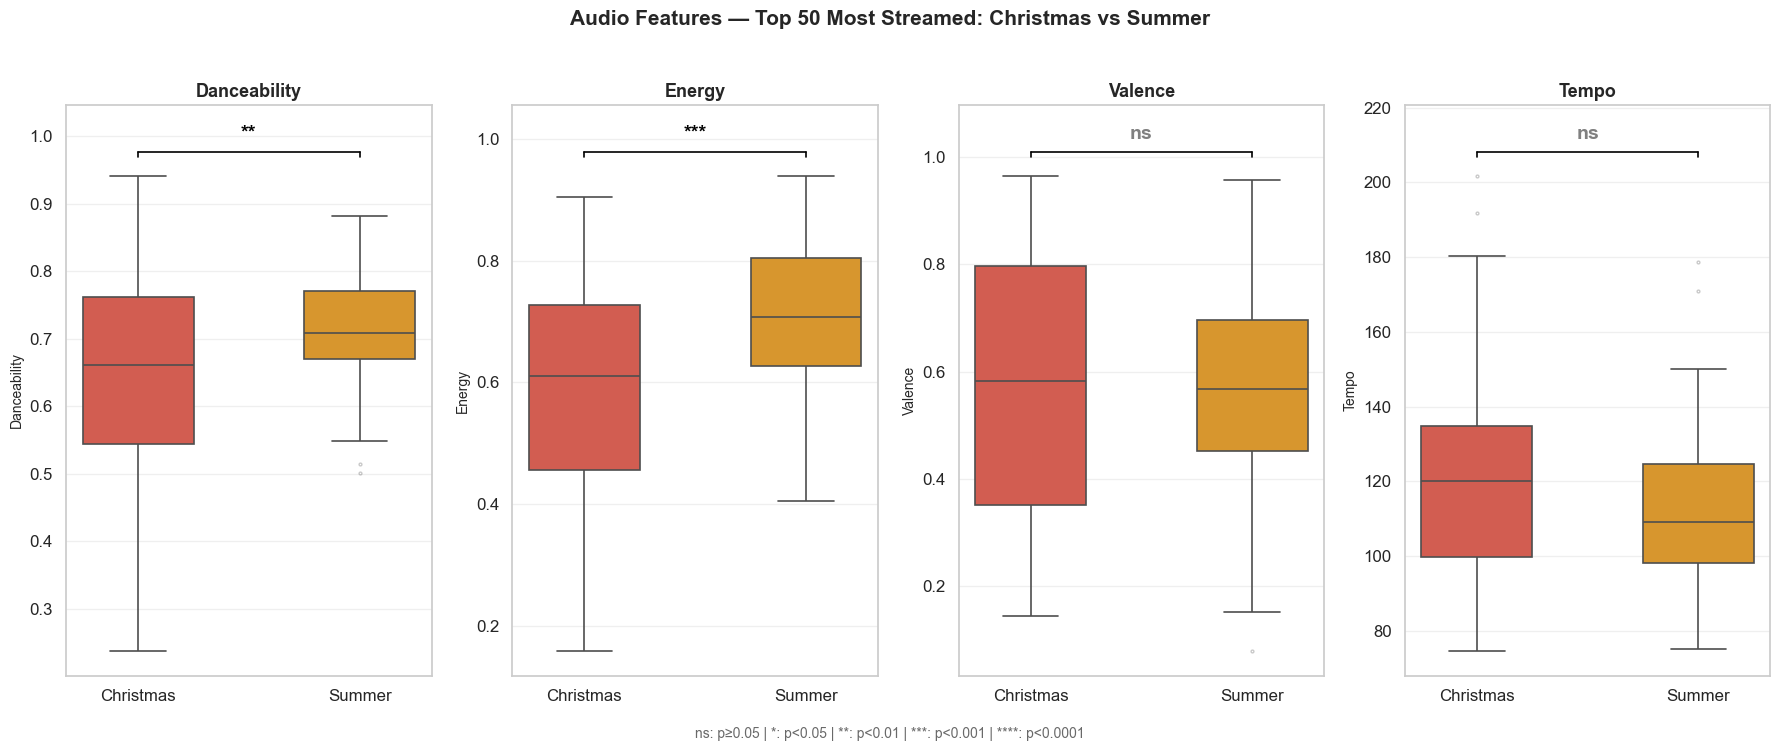

In [119]:
features = ['danceability', 'energy', 'valence', 'tempo']

# =============================================================
# 1. SIGNIFICANCE HELPER FUNCTION
# =============================================================
def get_stars(p_value):
    if p_value < 0.0001:
        return '****'
    elif p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'          # not significant

# =============================================================
# 2. COMPUTE P-VALUES (reusing same subsets as before)
# =============================================================
pvalues = {}

for feature in features:
    xmas_vals   = df_xmas_agg[feature].dropna()
    summer_vals = df_summer_agg[feature].dropna()
    _, p        = stats.ttest_ind(xmas_vals, summer_vals)
    pvalues[feature] = p

# =============================================================
# 3. REBUILD STACKED DATAFRAME FOR SEABORN
# =============================================================
df_xmas_plot   = df_xmas_agg.copy();   df_xmas_plot['season']   = 'Christmas'
df_summer_plot = df_summer_agg.copy(); df_summer_plot['season'] = 'Summer'
df_seasonal    = pd.concat([df_xmas_plot, df_summer_plot])

palette = {'Christmas': '#e74c3c', 'Summer': '#f39c12'}

# =============================================================
# 4. PLOT WITH SIGNIFICANCE ANNOTATIONS
# =============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 7))

for ax, feature in zip(axes, features):
    sns.boxplot(
        data      = df_seasonal,
        x         = 'season',
        y         = feature,
        hue       = 'season',
        palette   = palette,
        legend    = False,
        width     = 0.5,
        linewidth = 1.2,
        flierprops= dict(marker='o', markersize=2, alpha=0.3),
        ax        = ax
    )

    # --- Significance bar & stars ---
    stars   = get_stars(pvalues[feature])
    y_max   = df_seasonal[feature].max()
    y_range = df_seasonal[feature].max() - df_seasonal[feature].min()
    y_bar   = y_max + y_range * 0.05   # bar sits 5% above max value
    y_text  = y_bar + y_range * 0.02   # stars sit just above the bar

    # Draw the horizontal bracket
    ax.plot([0, 1], [y_bar, y_bar], color='black', linewidth=1.2)
    ax.plot([0, 0], [y_bar - y_range*0.01, y_bar], color='black', linewidth=1.2)
    ax.plot([1, 1], [y_bar - y_range*0.01, y_bar], color='black', linewidth=1.2)

    # Color-code: grey for ns, black for significant
    star_color = 'grey' if stars == 'ns' else 'black'
    ax.text(0.5, y_text, stars, ha='center', va='bottom',
            fontsize=14, fontweight='bold', color=star_color)

    # Extend y-axis to make room for annotation
    ax.set_ylim(top=y_text + y_range * 0.08)

    ax.set_title(feature.capitalize(), fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(feature.capitalize(), fontsize=10)
    ax.grid(axis='y', alpha=0.3)

# --- Legend for stars ---
legend_text = "ns: p≥0.05 | *: p<0.05 | **: p<0.01 | ***: p<0.001 | ****: p<0.0001"
fig.text(0.5, -0.02, legend_text, ha='center', fontsize=10, color='dimgray')

fig.suptitle(
    'Audio Features — Top 50 Most Streamed: Christmas vs Summer',
    fontsize=15, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()